# 2D MT Forward Modelling & Inversion — New Synthetic Model

This notebook combines and updates the logic from two source notebooks:

- **`2_2d_forward_modelling.ipynb`** — builds a mesh, defines a conductivity model, and runs 2D NSEM (MT) forward modelling for the TE and TM modes.
- **`7_2d_inversion_synthetic.ipynb`** — takes MT soundings and inverts them for a 2D conductivity model using SimPEG's deterministic (Tikhonov) inversion framework.

**New survey / model configuration used here:**

| Parameter | Value |
|---|---|
| Number of stations | 10 |
| Station spacing | 6 km |
| Frequency range | 400 Hz → 0.01 Hz (broadband MT, log-spaced) |
| Core domain (Easting × Depth) | 60 km × 30 km |
| Background resistivity | 100 Ω·m |
| Anomaly 1 | **Resistor**, 1000 Ω·m |
| Anomaly 2 | **Conductor**, 10 Ω·m |

The mesh is **not** hand-tuned: its smallest cell size and its padding distances are derived automatically from the EM **skin depth** at the highest/lowest survey frequencies, using `geoana.em.fdem.skin_depth`, exactly as in the source notebooks' `generate_2d_mesh_for_mt` helper (kept here, with two small corrections noted inline).


## 0. Imports

Same stack as the source notebooks. `pymatsolver.Pardiso` is optional (it needs Intel MKL/`pydiso`); we use SimPEG's `get_default_solver()` instead so the notebook runs anywhere, and it will pick Pardiso automatically if it is installed.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")  # suppress benign SimPEG/discretize deprecation chatter

import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import discretize
import discretize.utils as dis_utils
from geoana.em.fdem import skin_depth

from simpeg.electromagnetics import natural_source as nsem
from simpeg import (
    maps, utils, optimization, inversion, inverse_problem,
    directives, data_misfit, regularization, data,
)
from simpeg.utils import get_default_solver

plt.rcParams["font.size"] = 12
np.random.seed(0)  # reproducible noise realization

## 1. Survey Design

10 stations at the surface (z = 0), spaced exactly 6 km apart and centred on Easting = 0 so they sit symmetrically inside the 60 km core domain. Frequencies are broadband MT, log-spaced from 400 Hz down to 0.01 Hz (period 2.5 ms – 100 s).

In [2]:
# --- Receiver stations ---------------------------------------------------
n_rx = 10
d_station = 6_000.0  # m (6 km spacing)

x0 = (n_rx - 1) * d_station / 2.0          # centers the array on Easting = 0
rx_x = np.arange(n_rx) * d_station - x0
rx_locs = np.c_[rx_x, np.zeros(n_rx)]      # (x, z) at the surface

# --- Frequencies -----------------------------------------------------------
frequencies = np.logspace(np.log10(400.0), np.log10(0.01), 25)  # Hz, high -> low
n_freq = len(frequencies)

print(f"Station Eastings (km): {rx_locs[:, 0] / 1e3}")
print(f"Station spacing check: {np.diff(rx_locs[:, 0])} m (should all be {d_station:.0f} m)")
print(f"Array span: {(rx_locs[:, 0].max() - rx_locs[:, 0].min()) / 1e3:.1f} km "
      f"(fits inside the 60 km core domain)")
print(f"\n{n_freq} frequencies from {frequencies.max():.1f} Hz to {frequencies.min():.3f} Hz")

Station Eastings (km): [-27. -21. -15.  -9.  -3.   3.   9.  15.  21.  27.]
Station spacing check: [6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000.] m (should all be 6000 m)
Array span: 54.0 km (fits inside the 60 km core domain)

25 frequencies from 400.0 Hz to 0.010 Hz


## 2. Mesh Design — sized dynamically from the EM skin depth

`generate_2d_mesh_for_mt` is the same helper used in both source notebooks. Given the receiver
spacing, the frequency band and a background resistivity, it:

1. Sets the smallest cell size `dz_min`/`dx_min` so that the **highest frequency** (shallowest skin depth)
   is still resolved with several cells per skin depth.
2. Grows cells geometrically with depth/distance until the **lowest frequency's** skin depth
   (scaled by a safety factor) is reached — this sets how far the mesh must be padded so that the
   artificial boundary condition does not contaminate the fields at depth/laterally.

**Note on the 60 km × 30 km domain:** that's the *core region of interest* — where the two anomalies
live and where results are plotted (matching the request). The *total* mesh, including the
skin-depth padding needed for the 0.01 Hz sounding, is necessarily much larger (a well-known
requirement in MT modelling — long periods need deep, wide padding to avoid boundary reflections).
This mirrors exactly how the source notebooks used the function: the plotted domain and the full
mesh extent are different things.

Two small bugs in the source notebooks' copies of this function are fixed here:
- `skin_depth(frequency, sigma)` takes *(frequency, conductivity)* in that order; both source
  notebooks called it with the arguments swapped when computing the padding distances `lz`/`lx_pad`
  (harmless there only because their example values for σ and f happened to be numerically equal).
- The lateral padding block used an undefined variable (`csx`) in the forward-modelling notebook;
  fixed to use `dx_min` consistently (as the inversion notebook already did).


In [3]:
def generate_2d_mesh_for_mt(
    rx_locs, frequencies, sigma_background,
    z_factor_max=5,       # controls the finest cell size (relative to skin depth at f_max)
    pfz_down=1.15,        # vertical expansion factor going down from the surface
    pfz_up=1.5,           # vertical expansion factor going up into the air layer
    npadz_up=5,           # number of air-side padding cells
    x_factor_max=2,       # controls how far the lateral padding must reach (skin depths)
    spacing_factor=4,     # smallest horizontal cell = station spacing / spacing_factor
    pfx=1.5,               # lateral expansion factor
    n_max=1000,
):
    '''Generate a 2D TensorMesh for MT forward modelling / inversion.

    Cell sizes and padding distances are derived from the EM skin depth so that the
    mesh automatically adapts to a new frequency band or background resistivity.
    '''
    f_min, f_max = frequencies.min(), frequencies.max()

    # --- vertical discretization ---
    dz_min = np.round(skin_depth(f_max, sigma_background) / z_factor_max)
    lz = skin_depth(f_min, sigma_background) * z_factor_max  # required depth of padding
    for nz_down in range(n_max):
        hz_down = dz_min * pfz_down ** np.arange(nz_down)[::-1]
        if hz_down.sum() > lz:
            break
    hz_up = dis_utils.unpack_widths([(dz_min, npadz_up, pfz_up)])
    hz = np.r_[hz_down, hz_up]

    # --- lateral discretization ---
    d_station = np.diff(rx_locs[:, 0]).min()
    dx_min = np.round(d_station / spacing_factor)
    lx = rx_locs[:, 0].max() - rx_locs[:, 0].min()
    ncx = int(lx / dx_min)                                    # uniform core cells spanning the array
    lx_pad = skin_depth(f_min, sigma_background) * x_factor_max  # required lateral padding
    for npadx in range(n_max):
        hx_pad = dis_utils.unpack_widths([(dx_min, npadx, -pfx)])
        if hx_pad.sum() > lx_pad:
            break
    hx = [(dx_min, npadx, -pfx), (dx_min, ncx), (dx_min, npadx, pfx)]

    mesh = discretize.TensorMesh([hx, hz])
    mesh.origin = np.r_[-mesh.h[0][:npadx].sum() + rx_locs[:, 0].min(), -hz_down.sum()]
    return mesh


rho_background = 100.0                  # Ohm-m
sigma_background = 1.0 / rho_background  # S/m

mesh = generate_2d_mesh_for_mt(rx_locs, frequencies, sigma_background)
print(mesh)
print(f"\nSmallest cell size: {mesh.h[0].min():.0f} m (x), {mesh.h[1].min():.0f} m (z)")
print(f"Total mesh extent:  {(mesh.nodes_x.max()-mesh.nodes_x.min())/1e3:.0f} km (x), "
      f"{(mesh.nodes_y.max()-mesh.nodes_y.min())/1e3:.0f} km (z)  <- padded for numerical accuracy")


  TensorMesh: 2,756 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     52   -137,830.08    137,830.08  1,500.00 38,443.36    1.50
   y     53   -272,800.24        989.06     50.00 35,626.12    1.50



Smallest cell size: 1500 m (x), 50 m (z)
Total mesh extent:  276 km (x), 274 km (z)  <- padded for numerical accuracy


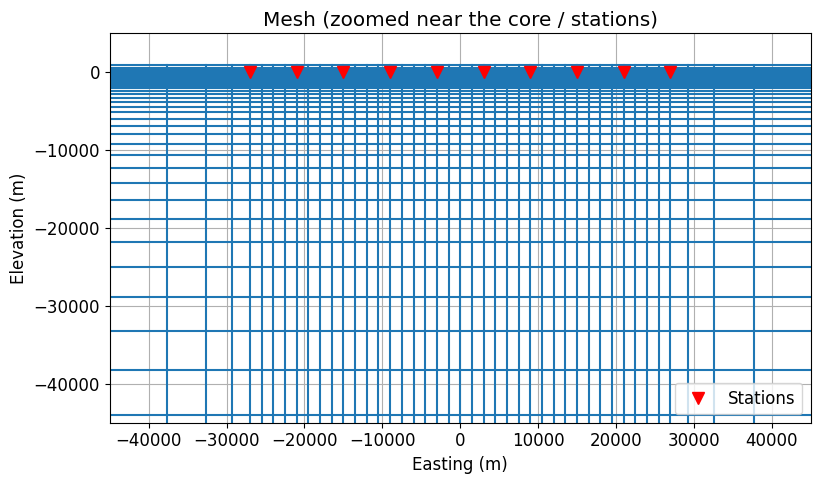

In [4]:
# Active cells = below the surface (z < 0); everything above is "air"
ind_active = mesh.cell_centers[:, 1] < 0.0
sigma_air = 1e-8  # S/m

fig, ax = plt.subplots(figsize=(9, 5))
mesh.plot_grid(ax=ax)
ax.plot(rx_locs[:, 0], rx_locs[:, 1], "rv", markersize=8, label="Stations")
ax.set_xlim(-45_000, 45_000)
ax.set_ylim(-45_000, 5_000)
ax.set_aspect(1)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Elevation (m)")
ax.set_title("Mesh (zoomed near the core / stations)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 3. True (Synthetic) Conductivity Model

Background of 100 Ω·m, with two anomalies placed at clearly different depths **and** eastings:

- **Resistor** (1000 Ω·m): shallow-to-mid crust, **west** of center (x ≈ −20 to −6 km, depth ≈ 4–14 km).
- **Conductor** (10 Ω·m): deeper crust, **east** of center (x ≈ 4 to 20 km, depth ≈ 16–26 km).

Both fit comfortably inside the 60 km × 30 km core domain, well within reach of the 10-station array.

In [5]:
cells = mesh.cell_centers

rho_resistor = 1000.0   # Ohm-m
rho_conductor = 10.0    # Ohm-m

sigma_true = np.ones(mesh.n_cells) * sigma_background

# Anomaly 1: Resistor -- west side, mid-crustal depth
blk_resistor = utils.model_builder.get_indices_block(
    np.r_[-20_000, -14_000], np.r_[-6_000, -4_000], cells
)
sigma_true[blk_resistor] = 1.0 / rho_resistor

# Anomaly 2: Conductor -- east side, deeper
blk_conductor = utils.model_builder.get_indices_block(
    np.r_[4_000, -26_000], np.r_[20_000, -16_000], cells
)
sigma_true[blk_conductor] = 1.0 / rho_conductor

sigma_true[~ind_active] = sigma_air  # air cells

print(f"Resistor block:  {blk_resistor.size} cells, rho = {rho_resistor} Ohm-m")
print(f"Conductor block: {blk_conductor.size} cells, rho = {rho_conductor} Ohm-m")

Resistor block:  81 cells, rho = 1000.0 Ohm-m
Conductor block: 30 cells, rho = 10.0 Ohm-m


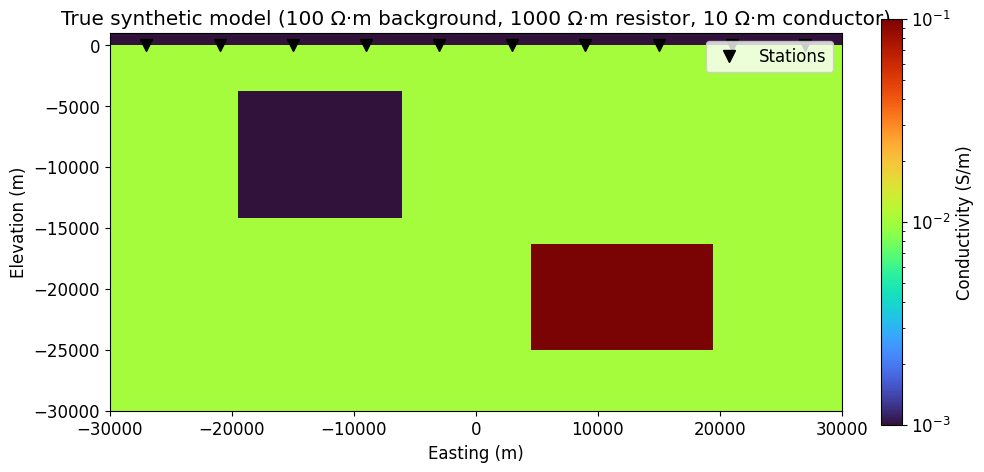

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
out = mesh.plot_image(
    sigma_true, ax=ax, grid=False,
    pcolor_opts={"norm": LogNorm(vmin=1e-3, vmax=1e-1), "cmap": "turbo"},
    range_x=(-30_000, 30_000), range_y=(-30_000, 1_000),
)
plt.colorbar(out[0], ax=ax, fraction=0.03, label="Conductivity (S/m)")
ax.plot(rx_locs[:, 0], rx_locs[:, 1], "kv", markersize=8, label="Stations")
ax.set_aspect(1)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Elevation (m)")
ax.set_title("True synthetic model (100 Ω·m background, 1000 Ω·m resistor, 10 Ω·m conductor)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 4. Forward Modelling (TE & TM modes)

Same `Simulation2DElectricField` (TM) / `Simulation2DMagneticField` (TE) pattern as the source
notebook, using an `Impedance` receiver for apparent resistivity and phase (the current SimPEG
receiver name — `PointNaturalSource` used in the old notebook has been renamed/removed).

In [7]:
solver = get_default_solver()
print(f"Using solver: {solver.__name__}")

# --- TM mode (Simulation2DElectricField), Zxy ---
rx_list_tm = [
    nsem.receivers.Impedance(rx_locs, orientation="xy", component="apparent_resistivity"),
    nsem.receivers.Impedance(rx_locs, orientation="xy", component="phase"),
]
src_list_tm = [nsem.sources.Planewave(rx_list_tm, frequency=f) for f in frequencies]
survey_tm = nsem.Survey(src_list_tm)

# --- TE mode (Simulation2DMagneticField), Zyx ---
rx_list_te = [
    nsem.receivers.Impedance(rx_locs, orientation="yx", component="apparent_resistivity"),
    nsem.receivers.Impedance(rx_locs, orientation="yx", component="phase"),
]
src_list_te = [nsem.sources.Planewave(rx_list_te, frequency=f) for f in frequencies]
survey_te = nsem.Survey(src_list_te)

# Simulations driven directly by the true conductivity model (no active-cell map needed here)
sim_tm_true = nsem.simulation.Simulation2DElectricField(mesh, survey=survey_tm, sigma=sigma_true, solver=solver)
sim_te_true = nsem.simulation.Simulation2DMagneticField(mesh, survey=survey_te, sigma=sigma_true, solver=solver)

t0 = time.time()
pred_te = sim_te_true.dpred()
pred_tm = sim_tm_true.dpred()
print(f"Forward modelling done in {time.time() - t0:.1f} s "
      f"({n_freq} frequencies x 2 modes x {n_rx} stations)")

# Reshape (n_freq, [app_res, phase], n_rx)
PRED_te = pred_te.reshape((n_freq, 2, n_rx))
PRED_tm = pred_tm.reshape((n_freq, 2, n_rx))
rho_app_te, phase_te = PRED_te[:, 0, :], PRED_te[:, 1, :]
rho_app_tm, phase_tm = PRED_tm[:, 0, :], PRED_tm[:, 1, :]

Using solver: SolverLU


Forward modelling done in 3.8 s (25 frequencies x 2 modes x 10 stations)


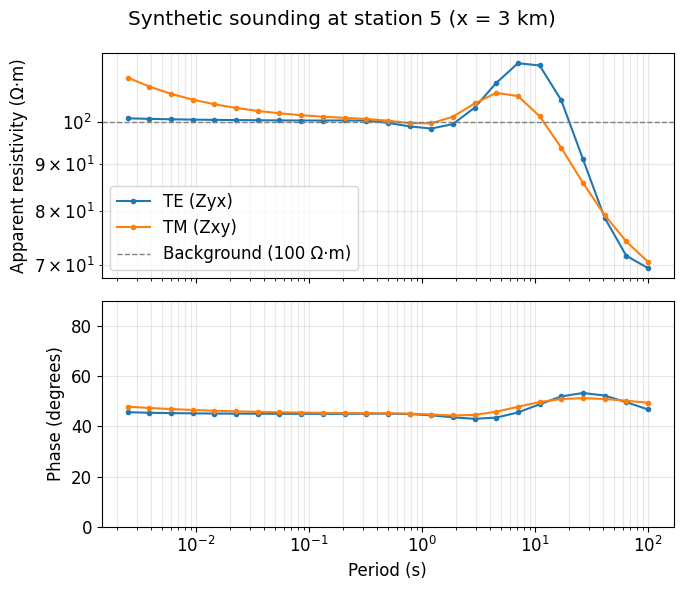

In [8]:
# Quick QC: sounding curve at the station nearest the center (between the two anomalies)
i_sounding = n_rx // 2
periods = 1.0 / frequencies

fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
axs[0].loglog(periods, rho_app_te[:, i_sounding], ".-", label="TE (Zyx)")
axs[0].loglog(periods, rho_app_tm[:, i_sounding], ".-", label="TM (Zxy)")
axs[0].axhline(rho_background, ls="--", color="gray", lw=1, label="Background (100 Ω·m)")
axs[0].set_ylabel("Apparent resistivity (Ω·m)")
axs[0].legend()
axs[0].grid(which="both", alpha=0.3)

axs[1].semilogx(periods, phase_te[:, i_sounding], ".-", label="TE")
axs[1].semilogx(periods, phase_tm[:, i_sounding] + 180, ".-", label="TM")
axs[1].set_ylim(0, 90)
axs[1].set_ylabel("Phase (degrees)")
axs[1].set_xlabel("Period (s)")
axs[1].grid(which="both", alpha=0.3)

fig.suptitle(f"Synthetic sounding at station {i_sounding} (x = {rx_locs[i_sounding, 0]/1e3:.0f} km)")
plt.tight_layout()
plt.show()

## 5. Add Realistic Noise → Synthetic Observed Data

Same noise model as the source notebooks: 5% Gaussian relative error on apparent resistivity,
2° Gaussian floor error on phase.

In [9]:
relative_error = 0.05  # 5% of |apparent resistivity|
floor_error = 2.0      # degrees, floor on phase uncertainty

noise_rho_te = relative_error * np.abs(rho_app_te) * np.random.randn(n_freq, n_rx)
noise_rho_tm = relative_error * np.abs(rho_app_tm) * np.random.randn(n_freq, n_rx)
noise_phase_te = floor_error * np.random.randn(n_freq, n_rx)
noise_phase_tm = floor_error * np.random.randn(n_freq, n_rx)

dobs_te = np.hstack((rho_app_te + noise_rho_te, phase_te + noise_phase_te)).flatten()
dobs_tm = np.hstack((rho_app_tm + noise_rho_tm, phase_tm + noise_phase_tm)).flatten()

std_te = np.hstack((relative_error * np.abs(rho_app_te), np.ones_like(phase_te) * floor_error)).flatten()
std_tm = np.hstack((relative_error * np.abs(rho_app_tm), np.ones_like(phase_tm) * floor_error)).flatten()

n_data = dobs_te.size + dobs_tm.size
print(f"Total data: {n_data} (= {n_freq} freq x 2 components x {n_rx} rx x 2 modes)")

Total data: 1000 (= 25 freq x 2 components x 10 rx x 2 modes)


## 6. Inversion Setup

Standard SimPEG deterministic-inversion recipe (same as the source inversion notebook):

- `InjectActiveCells` + `ExpMap` so the model is `log(conductivity)` on the active (below-surface)
  cells, with air fixed at `sigma_air`.
- Combined TE + TM `L2DataMisfit`.
- `Sparse` regularization used here in its **L2 (smooth)** mode (`alpha_s`, `alpha_x`, `alpha_z`) —
  the same starting point as the source notebook; switching on `reg.norms` + `Update_IRLS` is a
  natural next step for sharper, more compact anomalies (see §11).
- `InexactGaussNewton` optimizer with a cooling `beta` schedule and a target chi-squared misfit
  stopping criterion.

In [10]:
act_map = maps.InjectActiveCells(mesh, ind_active, np.log(sigma_air))
exp_map = maps.ExpMap(mesh=mesh)
sigma_map = exp_map * act_map  # model (log-conductivity on active cells) -> full sigma vector

# Simulations for the inversion use sigmaMap instead of a fixed sigma
sim_te = nsem.simulation.Simulation2DMagneticField(mesh, survey=survey_te, sigmaMap=sigma_map, solver=solver)
sim_tm = nsem.simulation.Simulation2DElectricField(mesh, survey=survey_tm, sigmaMap=sigma_map, solver=solver)

# Starting / reference model: uniform half-space at the (assumed known) background resistivity
rho_0 = 100.0
m0 = np.ones(int(ind_active.sum())) * np.log(1.0 / rho_0)

te_data_object = data.Data(survey_te, dobs=dobs_te, standard_deviation=std_te)
tm_data_object = data.Data(survey_tm, dobs=dobs_tm, standard_deviation=std_tm)
dmis_te = data_misfit.L2DataMisfit(data=te_data_object, simulation=sim_te)
dmis_tm = data_misfit.L2DataMisfit(data=tm_data_object, simulation=sim_tm)
dmis = dmis_te + dmis_tm

# Regularization: alpha_s ~ 0 (no pull to reference model beyond the halfspace),
# alpha_x smooths laterally, alpha_z ("alpha_y" in the 2D-mesh's regularization convention)
# smooths with depth.
alpha_s, alpha_x, alpha_z = 1e-10, 1.0, 0.5
reg = regularization.Sparse(
    mesh,
    active_cells=ind_active,
    reference_model=m0,
    alpha_s=alpha_s,
    alpha_x=alpha_x,
    alpha_y=alpha_z,  # mesh's 2nd dimension = depth in this 2D setup
    mapping=maps.IdentityMap(nP=int(ind_active.sum())),
)

opt = optimization.InexactGaussNewton(maxIter=30, maxIterCG=30, tolX=1e-30)
inv_prob = inverse_problem.BaseInvProblem(dmis, reg, opt)

save_dictionary = directives.SaveOutputDictEveryIteration()
save_dictionary.outDict = {}

directives_list = [
    directives.BetaEstimate_ByEig(beta0_ratio=1),
    directives.BetaSchedule(coolingFactor=2, coolingRate=1),
    save_dictionary,
    directives.TargetMisfit(chifact=1.0),
]

mt_inversion = inversion.BaseInversion(inv_prob, directiveList=directives_list)

## 7. Run the Inversion

In [11]:
t0 = time.time()
m_rec = mt_inversion.run(m0)
print(f"\nInversion finished in {time.time() - t0:.1f} s")

sigma_rec = np.ones(mesh.n_cells) * sigma_air
sigma_rec[ind_active] = np.exp(m_rec)

INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation2DMagneticField simulation with the 'is_symmetric=True` option set.




Running inversion with SimPEG v0.25.2


INFO: Directive TargetMisfit: Target data misfit is 1000.0


============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------


   0  6.73e-01  7.22e+03  0.00e+00  7.22e+03                                 


   1  6.73e-01  1.41e+03  1.52e+01  1.42e+03    1.33e+03      0              


   2  3.36e-01  9.78e+02  2.68e+01  9.87e+02    3.34e+02      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 4.2700e+02 <= tolF*(1+|f0|) = 7.2170e+02
0 : |xc-x_last| = 1.0622e+01 <= tolX*(1+|x0|) = 2.3107e-28
0 : |proj(x-g)-x|    = 3.3370e+02 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 3.3370e+02 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      30    <= iter          =      2
------------------------- DONE! -------------------------

Inversion finished in 56.9 s


## 8. Convergence (Tikhonov) Curve

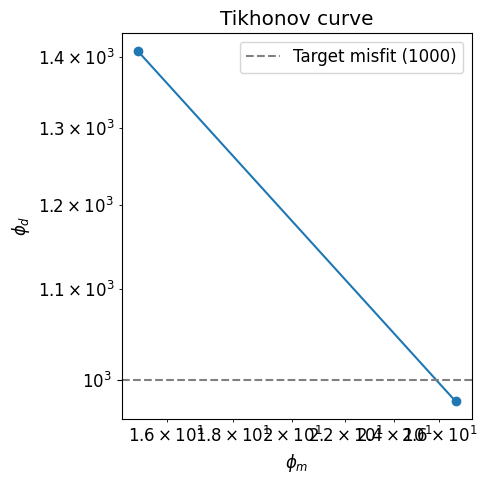

Iter |   beta   |   phi_d   |  phi_m
   1 | 3.36e-01 |    1409.4 |  15.19
   2 | 1.68e-01 |     978.5 |  26.77

Final chi-squared (phi_d / n_data): 0.98  (target = 1.0)


In [12]:
output_dict = save_dictionary.outDict
iterations = list(output_dict.keys())
phi_ds = np.array([output_dict[it]["phi_d"] for it in iterations])
phi_ms = np.array([output_dict[it]["phi_m"] for it in iterations])
betas = np.array([output_dict[it]["beta"] for it in iterations])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(phi_ms, phi_ds, "o-")
ax.axhline(n_data, ls="--", color="gray", label=f"Target misfit ({n_data})")
ax.set_xlabel(r"$\phi_m$")
ax.set_ylabel(r"$\phi_d$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Tikhonov curve")
ax.legend()
plt.tight_layout()
plt.show()

print("Iter |   beta   |   phi_d   |  phi_m")
for it in iterations:
    d = output_dict[it]
    print(f"{it:4d} | {d['beta']:8.2e} | {d['phi_d']:9.1f} | {d['phi_m']:6.2f}")
print(f"\nFinal chi-squared (phi_d / n_data): {phi_ds[-1] / n_data:.2f}  (target = 1.0)")

## 9. Compare True vs. Recovered Models

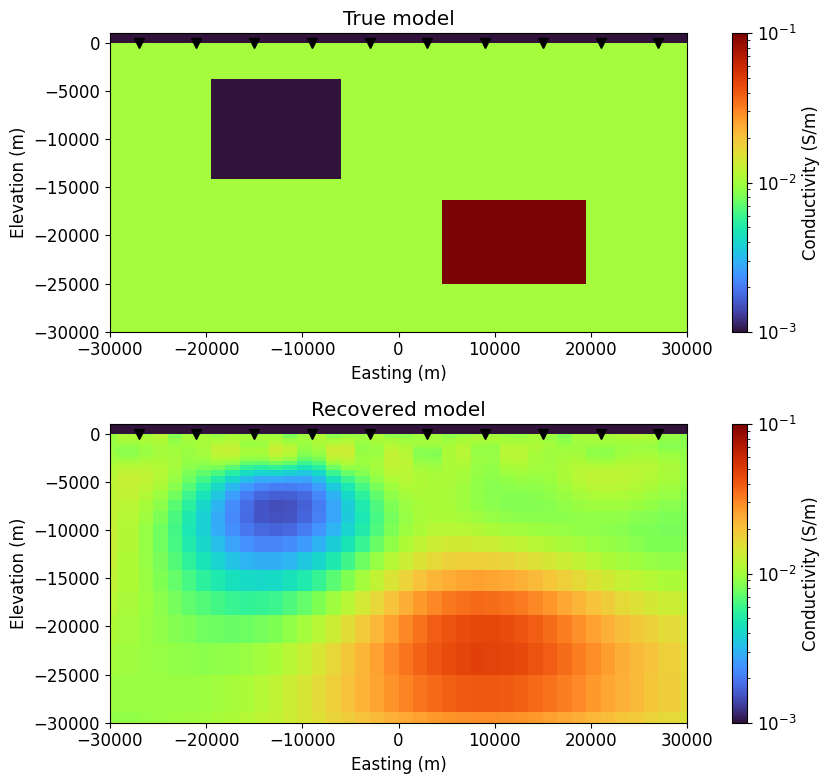

In [13]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
sigma_min, sigma_max = 1e-3, 1e-1

for ax, sig, title in zip(axs, [sigma_true, sigma_rec], ["True model", "Recovered model"]):
    out = mesh.plot_image(
        sig, ax=ax, grid=False,
        pcolor_opts={"norm": LogNorm(vmin=sigma_min, vmax=sigma_max), "cmap": "turbo"},
        range_x=(-30_000, 30_000), range_y=(-30_000, 1_000),
    )
    plt.colorbar(out[0], ax=ax, fraction=0.02, label="Conductivity (S/m)")
    ax.plot(rx_locs[:, 0], rx_locs[:, 1], "kv", markersize=7)
    ax.set_aspect(1)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Elevation (m)")
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 10. Check the Data Fit

Predicted (recovered model) vs. observed apparent resistivity/phase at one station.

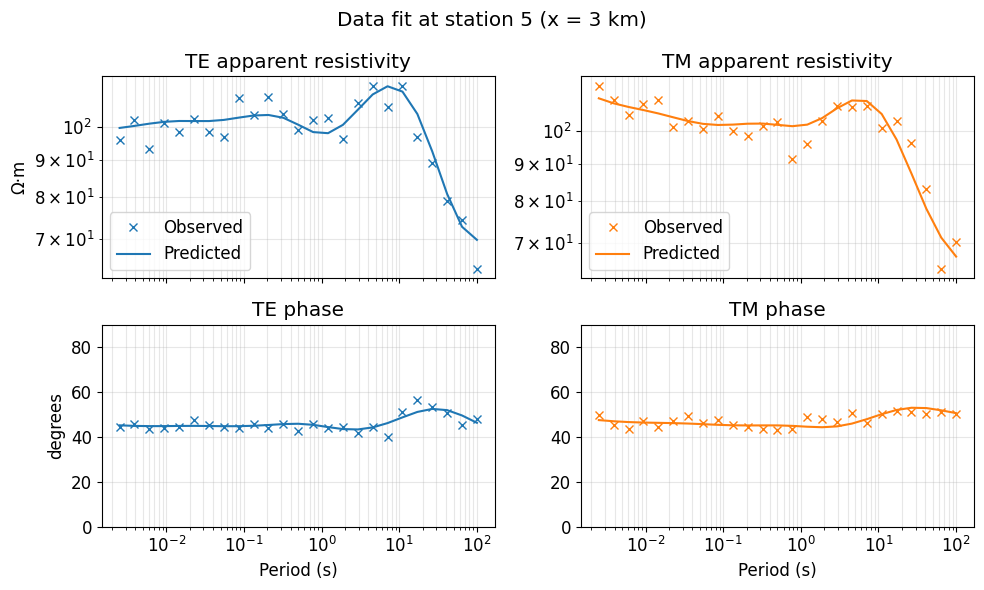

In [14]:
pred_te_rec = sim_te.dpred(m_rec).reshape((n_freq, 2, n_rx))
pred_tm_rec = sim_tm.dpred(m_rec).reshape((n_freq, 2, n_rx))

DOBS_te = dobs_te.reshape((n_freq, 2, n_rx))
DOBS_tm = dobs_tm.reshape((n_freq, 2, n_rx))

i_sounding = n_rx // 2
fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharex=True)

axs[0, 0].loglog(periods, DOBS_te[:, 0, i_sounding], "x", color="C0", label="Observed")
axs[0, 0].loglog(periods, pred_te_rec[:, 0, i_sounding], "-", color="C0", label="Predicted")
axs[0, 0].set_title("TE apparent resistivity")
axs[0, 0].set_ylabel("Ω·m")
axs[0, 0].legend()

axs[0, 1].loglog(periods, DOBS_tm[:, 0, i_sounding], "x", color="C1", label="Observed")
axs[0, 1].loglog(periods, pred_tm_rec[:, 0, i_sounding], "-", color="C1", label="Predicted")
axs[0, 1].set_title("TM apparent resistivity")
axs[0, 1].legend()

axs[1, 0].semilogx(periods, DOBS_te[:, 1, i_sounding], "x", color="C0")
axs[1, 0].semilogx(periods, pred_te_rec[:, 1, i_sounding], "-", color="C0")
axs[1, 0].set_title("TE phase")
axs[1, 0].set_ylabel("degrees")
axs[1, 0].set_xlabel("Period (s)")
axs[1, 0].set_ylim(0, 90)

axs[1, 1].semilogx(periods, DOBS_tm[:, 1, i_sounding] + 180, "x", color="C1")
axs[1, 1].semilogx(periods, pred_tm_rec[:, 1, i_sounding] + 180, "-", color="C1")
axs[1, 1].set_title("TM phase")
axs[1, 1].set_xlabel("Period (s)")
axs[1, 1].set_ylim(0, 90)

for ax in axs.flat:
    ax.grid(which="both", alpha=0.3)

fig.suptitle(f"Data fit at station {i_sounding} (x = {rx_locs[i_sounding, 0]/1e3:.0f} km)")
plt.tight_layout()
plt.show()

## 11. Summary & Things to Try

The recovered model (§9) locates both the shallower west-side resistor and the deeper east-side
conductor at roughly the correct positions and depths, smeared out by the smooth (L2) regularization
— exactly the expected behaviour for a Tikhonov inversion, and the data fit (§10) tracks the
noisy observations within their assigned uncertainties.

Ideas for further exploration, matching the learning goals of the original notebooks:

- **Station spacing / count** — resample `rx_locs`/`frequencies` to see how coverage affects
  resolution, especially of the deeper conductor.
- **Regularization weights** — try different `alpha_x`/`alpha_z` to trade off lateral vs. vertical
  smoothness.
- **Sparse norms / IRLS** — set `reg.norms = np.c_[p_s, p_x, p_z]` (e.g. all zeros for a "blocky"
  result) and swap `directives.TargetMisfit` for `directives.Update_IRLS` to sharpen the anomaly
  boundaries, closer to the true block-shaped bodies.
- **Target misfit (`chifact`)** — loosen/tighten to see the classic over/under-fitting trade-off on
  the Tikhonov curve.
- **Mesh tuning** — `z_factor_max`, `pfz_down`, `spacing_factor` in `generate_2d_mesh_for_mt`
  control the resolution/cost trade-off; the current settings (`pfz_down=1.15`) were chosen to keep
  several cells across each anomaly while keeping the mesh under ~3,000 cells for fast turnaround.
